In [1]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import util
from sklearn.metrics import roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV

In [2]:
X_train, X_test, y_train, y_test = util.generate_train_test_split()

Before SMOTE:
label
0    619054
1    213397
Name: count, dtype: int64

After SMOTE:
label
0    619054
1    619054
Name: count, dtype: int64


In [3]:

# param_grid = {
#     "svm__C": [0.1, 1, 10],
#     "svm__loss": ["hinge", "squared_hinge"],
# }


model = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("svm", LinearSVC(
        C=10,
        loss="squared_hinge",
        class_weight=None,
        random_state=42,
    ))
])


# search = GridSearchCV(
#     estimator=model,
#     param_grid=param_grid,
#     scoring="f1",
#     cv=5,
#     n_jobs=-1
# )


model.fit(X_train, y_train)
# best_model = model.best_estimator_

print("TRAIN RESULTS:")
y_pred_train = model.predict(X_train)
cm_train = confusion_matrix(y_train, y_pred_train)
print("Confusion matrix:\n", cm_train)
print("\nReport:\n", classification_report(y_train, y_pred_train, digits=4))
scores = model.decision_function(X_train)
print("ROC-AUC:", roc_auc_score(y_train, scores))
fpr, tpr, thresholds = roc_curve(y_train, scores)
auc_value = roc_auc_score(y_train, scores)



TRAIN RESULTS:
Confusion matrix:
 [[420455 198599]
 [213893 405161]]

Report:
               precision    recall  f1-score   support

           0     0.6628    0.6792    0.6709    619054
           1     0.6711    0.6545    0.6627    619054

    accuracy                         0.6668   1238108
   macro avg     0.6669    0.6668    0.6668   1238108
weighted avg     0.6669    0.6668    0.6668   1238108

ROC-AUC: 0.7374483874833306


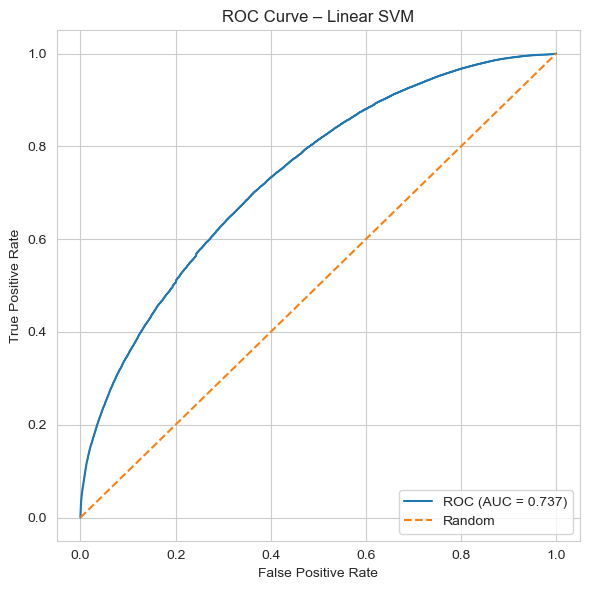

In [4]:
sns.set_style("whitegrid")

plt.figure(figsize=(6, 6))
sns.lineplot(x=fpr, y=tpr, label=f"ROC (AUC = {auc_value:.3f})")
sns.lineplot(x=[0, 1], y=[0, 1], linestyle="--", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Linear SVM")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()



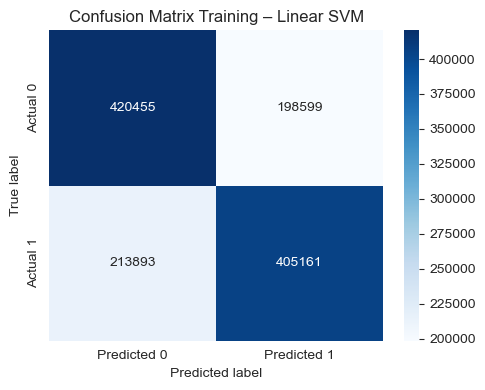

In [5]:
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_train,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"]
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix Training – Linear SVM")
plt.tight_layout()
plt.show()

In [9]:
print("TEST RESULTS:")
y_pred = model.predict(X_test)
cm_test = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm_test)
print("\nReport:\n", classification_report(y_test, y_pred, digits=4))
scores = model.decision_function(X_test)
print("ROC-AUC:", roc_auc_score(y_test, scores))


fpr, tpr, thresholds = roc_curve(y_test, scores)
auc_value = roc_auc_score(y_test, scores)


TEST RESULTS:
Confusion matrix:
 [[105048  49716]
 [ 18354  34995]]

Report:
               precision    recall  f1-score   support

           0     0.8513    0.6788    0.7553    154764
           1     0.4131    0.6560    0.5070     53349

    accuracy                         0.6729    208113
   macro avg     0.6322    0.6674    0.6311    208113
weighted avg     0.7389    0.6729    0.6916    208113

ROC-AUC: 0.7364585758830062


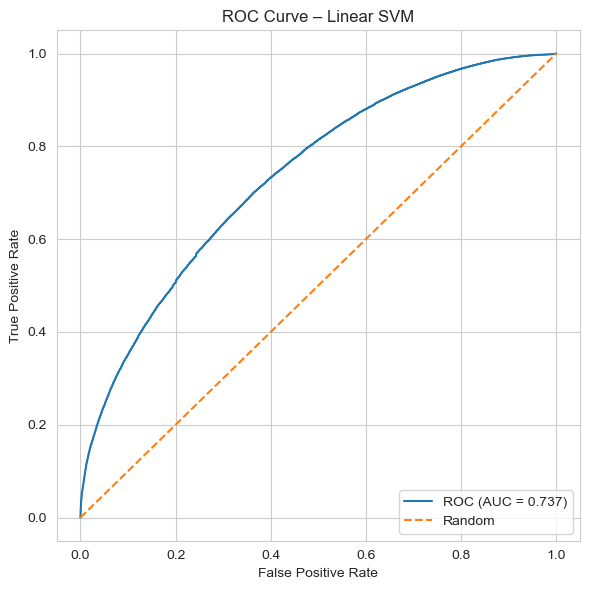

In [6]:
sns.set_style("whitegrid")

plt.figure(figsize=(6, 6))
sns.lineplot(x=fpr, y=tpr, label=f"ROC (AUC = {auc_value:.3f})")
sns.lineplot(x=[0, 1], y=[0, 1], linestyle="--", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Linear SVM")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


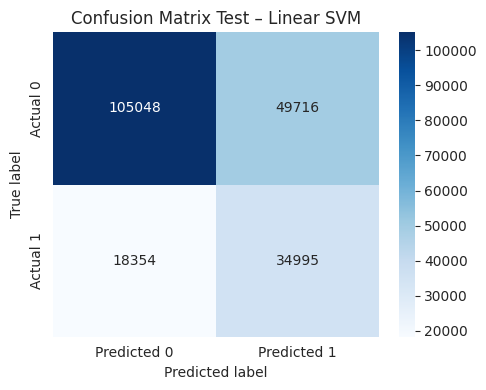

In [11]:
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_test,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"]
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix Test – Linear SVM")
plt.tight_layout()
plt.show()
